# Single-cell analysis: LiFi 1.0 (LED) vs LiFi 2.0 (VCSEL)

This notebook implements a single-cell analysis for the comparative study between LiFi 1.0 and LiFi 2.0. It is divided into two stages because each one answers a different question.

**Phase 1** investigates how the channel models differ when both technologies operate under the same conditions: identical transmit power and an identical receiver. The channel gain is analyzed in two steps: first without the receiver field of view (what each source can cover by itself) and then with the receiver FoV applied.

**Phase 2** investigates how both technologies perform under realistic operating conditions. In this case, each transmitter operates within its own practical constraints, allowing the impact of illumination and eye-safety requirements to be evaluated.

Every paper cited in this notebook is stored in the [`sources/`](sources/) folder.

**Table of contents**

- [Parameters used in this notebook](#Parameters-used-in-this-notebook)
- [1. References](#1.-References)
- [2. Common scenario](#2.-Common-scenario)
- [3. Phase 1: Single-cell channel comparison](#3.-Phase-1:-Single-cell-channel-comparison)
    - [3.1 Channel models and receiver FoV](#3.1-Channel-models-and-receiver-FoV)
    - [3.2 Source-only channel gain (without receiver FoV)](#3.2-Source-only-channel-gain-(without-receiver-FoV))
    - [3.3 Channel-gain maps with the receiver FoV applied](#3.3-Channel-gain-maps-with-the-receiver-FoV-applied)
    - [3.4 Channel gain vs. horizontal distance](#3.4-Channel-gain-vs.-horizontal-distance)
    - [3.5 Received power, SNR and achievable rate at the normalization power](#3.5-Received-power,-SNR-and-achievable-rate-at-the-normalization-power)
    - [3.6 Coverage vs. SNR threshold](#3.6-Coverage-vs.-SNR-threshold)
    - [3.7 Phase 1 discussion](#3.7-Phase-1-discussion)
- [4. Phase 2: Realistic single-cell analysis](#4.-Phase-2:-Realistic-single-cell-analysis)
    - [4.1 LiFi 1.0 power - illuminance requirement](#4.1-LiFi-1.0-power---illuminance-requirement)
    - [4.2 LiFi 2.0 power - eye safety IEC 60825-1](#4.2-LiFi-2.0-power---eye-safety-IEC-60825-1)
        - [4.2.1 Choosing a physically consistent beam waist](#4.2.1-Choosing-a-physically-consistent-beam-waist)
        - [4.2.2 Sensitivity to the beam waist](#4.2.2-Sensitivity-to-the-beam-waist)
    - [4.3 Spectral consideration - wavelength-dependent responsivity](#4.3-Spectral-consideration---wavelength-dependent-responsivity)
    - [4.4 Coverage under realistic power](#4.4-Coverage-under-realistic-power)
    - [4.5 Summary and energy efficiency](#4.5-Summary-and-energy-efficiency)
- [5. Summary: LiFi 1.0 vs LiFi 2.0 so far](#5.-Summary:-LiFi-1.0-vs-LiFi-2.0-so-far)
- [6. Transition to the multi-cell analysis](#6.-Transition-to-the-multi-cell-analysis)
    - [6.1 Why not just add more power at one point?](#6.1-Why-not-just-add-more-power-at-one-point?)
    - [6.2 Tiling multiple beams within a single cell](#6.2-Tiling-multiple-beams-within-a-single-cell)


## Parameters used in this notebook

These are the main parameters that are used in this analysis:

**The room and the devices**

| Parameter | Name | What it means | Value |
|:---|:---|:---|:---|
| `ROOM_X`, `ROOM_Y` | Room dimensions | Size of the room floor | 5 m x 5 m |
| `TX_HEIGHT` | Transmitter height | Height of the transmitter (LED or VCSEL), on the ceiling | 3 m |
| `RX_HEIGHT` | Receiver height | Height of the receiver, like a desk | 1 m |
| `theta` | Incidence / irradiance angle | Angle between "straight up" and the line joining Tx and Rx: 0 deg directly below the Tx, larger toward the edges | derived |
| `APD` | Photodetector active area | Size of the light-sensing area on the receiver | 1 cm^2 |
| `RHO` | Photodetector responsivity | How much electrical current comes out per watt of light in | 1 A/W (ideal baseline) |

**LiFi 1.0: LED**

| Parameter | Name | What it means | Value |
|:---|:---|:---|:---|
| `PHI_HALF_DEG` | LED half-power semiangle | How wide the LED's light cone is (bigger = more spread out, like a lamp) | 80 deg |
| `m_led` | Lambertian order | Number describing how focused the LED beam is, calculated from the angle above | derived |

**LiFi 2.0: VCSEL (laser)**

| Parameter | Name | What it means | Value |
|:---|:---|:---|:---|
| `W0` | Beam waist | How narrow the laser beam is right at the source | 5 micrometers (see Section 4.2.1 for why) |
| `LAMBDA` | Wavelength | Color of the laser light | 950 nm (infrared, invisible) |
| `zR` | Rayleigh range | Distance over which the beam stays roughly as narrow as at the source, before it starts visibly spreading out | derived |

**The receiver's "field of view"**

| Parameter | Name | What it means | Value |
|:---|:---|:---|:---|
| `PSI_C_DEG` | Receiver FoV semiangle | How wide an angle the receiver can "see" light from, like a camera's field of view | 40 deg |
| `N_LENS` | Concentrator refractive index | Refractive index of the small lens (concentrator) placed in front of the receiver to collect extra light | 1.5 |
| `G_CONC` | Concentrator gain | How much the concentrator lens boosts the signal for light arriving inside the FoV | derived |
| `r_fov` | FoV footprint radius | Radius, on the desk plane, of the circle the receiver can actually "see" | derived |

**Signal quality and speed**

| Parameter | Name | What it means | Value |
|:---|:---|:---|:---|
| `N0` | Noise power spectral density | Amount of background electronic noise the receiver has to fight against | 2.5e-20 W/Hz |
| `B1`, `B2` | Bandwidth | How fast each technology could go  | 20 MHz (LED) / 2 GHz (VCSEL) |
| `PTX_NORM` | Normalization transmit power | A shared, made-up transmit power used only in Phase 1, so both technologies are compared on equal terms | 1 W |

**Phase 2**

| Parameter | Name | What it means | Value |
|:---|:---|:---|:---|
| `E_TARGET_LUX` | Illuminance target | How bright a desk/task area needs to be for people to work comfortably (EN 12464-1 office task-area value) | 500 lux |
| `TASK_HALF` | Task-area footprint | Half-width of the desk-sized patch under the Tx over which that 500 lux target is averaged (EN 12464-1 defines the target over the *task area*, not the whole room -- Section 4.1) | 0.5 m (1x1 m patch) |
| `PTX_LED_REALISTIC` | Realistic LED transmit power | LED power needed to reach 500 lux averaged over that task area | derived |
| `PTX_VCSEL_EYESAFE` | Eye-safe transmit power | The most power a single VCSEL can use without being an eye hazard (IEC 60825-1); used as LiFi 2.0's realistic power throughout | derived |
| `PTX_VCSEL_EXPERIMENTAL` | Experimental transmit power | A real transmit power from a published VCSEL experiment, kept only as a literature cross-check where it is introduced (Section 4.2) -- not used anywhere else | 5 mW |
| `GAMMA_TH_DB` | Coverage SNR threshold | The signal-quality bar a point must clear to count as "covered"; the low end of the 10-50 dB range `[RIS-VLC]` associates with 2-256 PAM at BER=1e-6, the same threshold adopted in the multi-cell notebook | 10 dB |

**Eye safety (Section 4.2)**

| Parameter | Name | What it means | Value |
|:---|:---|:---|:---|
| `MPE` | Maximum Permissible Exposure | The highest light intensity still considered safe for the human eye, set by the IEC 60825-1 standard | derived from wavelength |
| `theta_div` | Beam divergence angle | How quickly the laser beam spreads out as it travels away from the source | derived |
| `rp` | Pupil radius | Worst-case (dilated) size of a human pupil, used as the "target" the laser must not overexpose | 3.5 mm |
| `zhaz` | Hazard distance | The distance at which the eye-safety limit is actually evaluated | derived |
| `eta` | Pupil capture fraction | Fraction of the laser beam's power that could enter an eye's pupil at the hazard distance | derived |

Everything else in the notebook (`H_led`, `H_vcsel`, `SNR_...`, `R_...`, etc.) is calculated from these parameters.

## 1. References

| Key | Paper | Used for |
|---|---|---|
| `[RIS-VLC]` | [Resource Allocation Exploiting Reflective Surfaces to Minimize the Outage Probability in VLC](<sources/Resource_Allocation_Exploiting_Reflective_Surfaces_to_Minimize_the_Outage_Probability_in_VLC%20(1).pdf>) | LiFi 1.0 Lambertian LOS channel — eq. (1); optical power → illuminance — eq. (25); SNR — eq. (12); FoV coverage radius — eq. (11); parameters ($K_{e/v}$, FoV, $B$, $N_0$) — Table III |
| `[VCSEL-Precoding]` | Safi et al., [Energy-Efficient Precoding for Dense VCSEL-Based OWC Systems Under a Cooperative Broadcast Model](<sources/Energy-Efficient_Precoding_for_Dense_VCSEL-Based_OWC_Systems_Und.pdf>) | LiFi 2.0 single-VCSEL Gaussian-beam channel — eqs. (2)–(8); non-imaging concentrator gain (Kahn–Barry model), applied here to the receiver of *both* technologies — eq. (8); parameters ($w_0$, $\lambda$, $n$, $A_{PD}$, $\rho$, $B$) — Table I |
| `[Capacity-Bound]` | Wang et al., [Tight Bounds on Channel Capacity for Dimmable Visible Light Communications](<sources/TightBoundsonChannelCapacityforDimmableVisibleLightCommunications.pdf>) | Achievable-rate lower bound for both technologies — eq. (37) (cited as [39] in `[RIS-VLC]` and [31] in `[VCSEL-Precoding]`) |
| `[Eye-Safety]` | Soltani et al., [Safety Analysis for Laser-Based Optical Wireless Communications: A Tutorial](<sources/Safety_Analysis_for_Laser-Based_Optical_Wireless_Communications_A_Tutorial.pdf>) | Max eye-safe CW power of a single-mode VCSEL — Algorithm 1, eq. (36), divergence eq. (8); IEC 60825-1:2014 near-IR MPE — Table 4 |
| `[VCSEL-70Gbps]` | Kazemi et al. 2025, [Achieving 70 Gb/s Over a VCSEL-Based Optical Wireless Link Using a Multi-Mode Fiber-Coupled Receiver](<sources/achieving_70gbs_vcsel_wirelesslink_multimodefiber.pdf>) | Experimental single-VCSEL operating power (~5 mW, 940 nm) as an eye-safety cross-check — Table I / abstract |


----

## 2. Common scenario

Everything here stays the same across both phases and both technologies: the room, the ceiling/desk height, the transmitter position, the photodetector, and the receiver grid. The only parameters that change later on are the ones related to channel model (Phase 1) and the transmit power (Phase 2).


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# room and tx/rx geometry, shared by every cell in the code below 

ROOM_X, ROOM_Y = 5.0, 5.0 # room floor size [m], typical attocell footprint
TX_HEIGHT = 3.0 # tx height, mounted on the ceiling [m]
RX_HEIGHT = 1.0 # rx height, desk level [m]

TX_POS = np.array([ROOM_X / 2, ROOM_Y / 2, TX_HEIGHT]) # tx at the center of the ceiling
dz = TX_HEIGHT - RX_HEIGHT # vertical tx-rx separation [m]

APD = 1e-4 # photodetector active area A_PD [m^2] = 1 cm^2 ([RIS-VLC] Table III / [VCSEL-Precoding] Table I)
RHO = 1.0 # photodetector responsivity rho [A/W], same in both papers (see Section 4.3)

# receiver grid: N x N points covering the whole floor
N = 300
xs = np.linspace(0, ROOM_X, N)
ys = np.linspace(0, ROOM_Y, N)
X, Y = np.meshgrid(xs, ys)

r0 = np.sqrt((X - TX_POS[0])**2 + (Y - TX_POS[1])**2) # horizontal distance from tx to each rx point [m]
d3d = np.sqrt(r0**2 + dz**2) # straight-line tx-rx distance [m]
theta = np.arctan2(r0, dz) # irradiance/incidence angle seen from tx [rad]

print(f"Room {ROOM_X:.0f}x{ROOM_Y:.0f}x{TX_HEIGHT:.0f} m")
print(f"Tx-Rx vertical separation = {dz:.1f} m")

Room 5x5x3 m
Tx-Rx vertical separation = 2.0 m


## 3. Phase 1: Single-cell channel comparison

In this phase, everything is kept constant except the channel model: same room, same Tx/Rx geometry, same $A_{PD}$ and $\rho$, same treatment of the receiver FoV, and both transmitters send the same normalization power, $P_{tx} = 1\,\text{W}$

The 1 W value is set just so both technologies are compared under the exact same conditions.

### 3.1 Channel models and receiver FoV

Both technologies model the direct line-of-sight channel gain $H$ as a function of the horizontal distance $r_0$, the vertical separation $\Delta z$, the straight-line distance $d=\sqrt{r_0^2+\Delta z^2}$, and the incidence angle $\theta=\arctan(r_0/\Delta z)$ (see [Parameters used in this notebook](#Parameters-used-in-this-notebook)).

**LiFi 1.0: LED, Lambertian source (`[RIS-VLC]` eq. (1)):**

$$H_{LED}(\theta) = \frac{(m+1)\,A_{PD}}{2\pi d^2}\cos^{m}(\theta)\cos(\theta), \qquad m = \frac{-1}{\log_2\left(\cos(\Phi_{1/2})\right)}$$

$\Phi_{1/2}$ is the LED's half-power semiangle and $m$ is the Lambertian order: a wider $\Phi_{1/2}$ gives a smaller $m$, that is: a broader, flatter beam.

**LiFi 2.0: VCSEL, Gaussian beam (`[VCSEL-Precoding]` eqs. (2)-(7)):**

$$z_R=\frac{\pi w_0^2}{\lambda}, \qquad w(d)=w_0\sqrt{1+\left(\frac{d}{z_R}\right)^2}, \qquad H_{VCSEL}(r_0,d) = \frac{2\,A_{PD}}{\pi\,w(d)^2}\exp\!\left(\frac{-2r_0^2}{w(d)^2}\right)$$

$z_R$ is the Rayleigh range and $w(d)$ is the beam radius at distance $d$: close to the source the beam stays roughly $w_0$-wide, then widens once $d$ grows past $z_R$.

The **receiver side** is identical for both technologies. The field of view (FoV) is a property of the receiver, not the transmitter, so it must be identical for both if the comparison is to be fair:

- The reference papers use different semiangles (40° in `[RIS-VLC]` and 60° in `[VCSEL-Precoding]`) simply because they assume different receivers. Keeping those values would mean comparing two different receivers instead of the transmitters.

- We use one receiver model for both: a photodiode ($A_{PD} = 1\,\text{cm}^2$) with an optical concentrator ($n = 1.5$, $\Psi_c = 40°$, taken from `[RIS-VLC]`), following the standard Kahn-Barry model (gain $G = n^2/\sin^2\Psi_c$ inside the FoV, zero outside). This concentrator gain is the only change to `[RIS-VLC]`'s original LED equation, applied identically to both technologies so the receiver stays the same for both.

- The receiver is assumed to point straight up. Moving it would shift the coverage area, so the analysis is split: Section 3.2 shows the channel gain without the FoV restriction (each source's raw coverage capability), and Section 3.3 applies it.

In [2]:
# LiFi 1.0: LED, Lambertian, LOS only

# Channel model [RIS-VLC] eq. (1):  H_LoS = (m+1)*A_PD/(2*pi*d^2) * cos^m(phi) * cos(psi),  0 <= psi <= Psi

# Lambertian order  [RIS-VLC] eq. (1):  m = -1 / log2(cos(phi_1/2))

PHI_HALF_DEG = 80.0  # LED half-power semiangle [deg], [RIS-VLC] Table III
m_led = -1.0 / np.log2(np.cos(np.deg2rad(PHI_HALF_DEG)))  # Lambertian order

# emitter points down and rx points up => irradiance angle phi = incidence angle psi = theta
H_led_src = (m_led + 1) * APD / (2 * np.pi * d3d**2) * np.cos(theta)**m_led * np.cos(theta)

In [3]:
# LiFi 2.0: single VCSEL, Gaussian beam ([VCSEL-Precoding], Safi et al., eqs. (2)-(8))

W0 = 5e-6    # beam waist w0 at the VCSEL aperture [m]

LAMBDA = 950e-9 # VCSEL wavelength lambda [m], [VCSEL-Precoding] Table I

zR = np.pi * W0**2 / LAMBDA  # Rayleigh range of the beam [m], [VCSEL-Precoding] eq. (2)
wz = W0 * np.sqrt(1 + (d3d / zR)**2) # beam radius at distance d3d [m], [VCSEL-Precoding] eq. (6)
Z_irr = 2 / (np.pi * wz**2) * np.exp(-2 * r0**2 / wz**2) # Gaussian irradiance profile, [VCSEL-Precoding] eq. (7)
H_vcsel_src = Z_irr * APD # source-only VCSEL gain (PD, no concentrator)

In [4]:
# Receiver side: unified PD + concentrator, identical for BOTH 

PSI_C_DEG = 40.0  # receiver FoV semiangle Psi_c [deg], same for both technologies ([RIS-VLC] Table III lists 30/40/50)
N_LENS = 1.5  # concentrator refractive index n, [VCSEL-Precoding] eq. (8)

PSI_C = np.deg2rad(PSI_C_DEG)
G_CONC = N_LENS**2 / np.sin(PSI_C)**2  # non-imaging concentrator gain G, [VCSEL-Precoding] eq. (8) (Kahn-Barry)
in_fov = theta <= PSI_C # unified receiver FoV mask (receiver pointing straight up)
r_fov = dz * np.tan(PSI_C) # FoV footprint radius on the desk plane [m], [RIS-VLC] eq. (11)

# full channel gain = source shape x concentrator gain, zero outside the receiver FoV
H_led = np.where(in_fov, H_led_src * G_CONC, 0.0)
H_vcsel = np.where(in_fov, H_vcsel_src * G_CONC, 0.0)

print(f"m_led = {m_led:.3f}")
print(f"Unified receiver: Psi_c = {PSI_C_DEG:.0f} deg -> G_conc = {G_CONC:.3f}")
print(f"Receiver FoV footprint radius on the desk plane: {r_fov:.2f} m (same for both technologies)")
print(f"VCSEL beam radius on the desk plane: w(dz) = {W0*np.sqrt(1+(dz/zR)**2):.2f} m")

m_led = 0.396
Unified receiver: Psi_c = 40 deg -> G_conc = 5.446
Receiver FoV footprint radius on the desk plane: 1.68 m (same for both technologies)
VCSEL beam radius on the desk plane: w(dz) = 0.12 m


### 3.2 Source-only channel gain (without receiver FoV)

Before applying any receiver constraints, these maps show the gain each source delivers to the desk plane. This represents what a simple, upward-facing photodiode would receive without a concentrator or angular cut-off, showing the true coverage capability of each source independently of the user's receiver setup.

* The LED illuminates the entire room with a smooth Lambertian decay, and the Gaussian beam stays positive everywhere. Without receiver FoV limits, both sources reach the whole floor, just with very different intensity distributions.

* **The LED is highly uniform:** The gain varies by only about 10 dB from the center of the room to the corners, meaning the Lambertian pattern spreads the power almost evenly.

* **The VCSEL concentrates the power into a tiny spot:** almost all of it lands within well under 1% of the room's floor area (about 0.2%) around the beam axis (a spot only about 12 cm in radius at the desk plane); a short distance away the signal is not just weaker, it is genuinely negligible, unlike the LED's slow, room-wide decay.

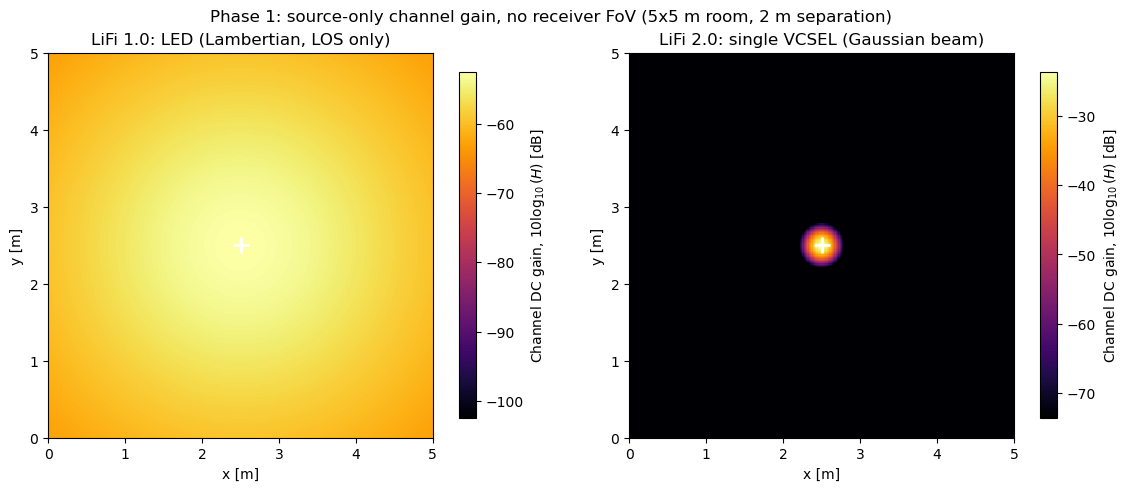

LED source-only gain: center = -52.6 dB, corner = -63.0 dB (drop = 10.4 dB)
VCSEL source-only gain: center = -23.7 dB, corner = negligible (the raw value underflows to -1829 dB


In [5]:
H_led_src_dB = 10 * np.log10(H_led_src)      # source-only gains are strictly positive, so no masking needed
H_vcsel_src_dB = 10 * np.log10(H_vcsel_src)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8), constrained_layout=True)
maps_src = [(H_led_src_dB,   "LiFi 1.0: LED (Lambertian, LOS only)"),
            (H_vcsel_src_dB, "LiFi 2.0: single VCSEL (Gaussian beam)")]

for ax, (H_dB, title) in zip(axes, maps_src):
    vmax = np.nanmax(H_dB)
    im = ax.pcolormesh(X, Y, H_dB, shading="auto", cmap="inferno", vmin=vmax - 50, vmax=vmax)
    ax.plot(*TX_POS[:2], "w+", markersize=12, mew=2)
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.set_xlim(0, ROOM_X)
    ax.set_ylim(0, ROOM_Y)
    fig.colorbar(im, ax=ax, label=r"Channel DC gain, $10\log_{10}(H)$ [dB]", shrink=0.9)
fig.suptitle("Phase 1: source-only channel gain, no receiver FoV "
             f"({ROOM_X:.0f}x{ROOM_Y:.0f} m room, {dz:.0f} m separation)")
plt.show()

print(f"LED source-only gain: center = {H_led_src_dB.max():.1f} dB, "
      f"corner = {H_led_src_dB.min():.1f} dB (drop = {H_led_src_dB.max()-H_led_src_dB.min():.1f} dB)")
print(f"VCSEL source-only gain: center = {H_vcsel_src_dB.max():.1f} dB, corner = negligible "
      f"(the raw value underflows to {H_vcsel_src_dB.min():.0f} dB")

### 3.3 Channel-gain maps with the receiver FoV applied

Same channel shape as above, but now seen by the actual receiver: concentrator gain $G$ inside the FoV, zero outside.

A receiver only "sees" the transmitter while the incidence angle stays within its field-of-view semiangle $\Psi_c$. With the receiver pointing straight up, on the desk plane this maps to a coverage *disk* of radius

$$r_\text{FoV} = \Delta z\,\tan(\Psi_c),$$

which with $\Psi_c = 40°$ and $\Delta z = 2$ m gives $r_\text{FoV} = 1.68$ m for both technologies. Outside this disk the non-imaging concentrator gain is zero, so $H=0$ and $10\log_{10}H\to-\infty$ (in black).

- The difference with respect to Section 3.2 is entirely caused by the receiver: everything outside the FoV disk is cut to exactly zero (the shapes inside the disk are unchanged from 3.2), regardless of how much light the source delivers there.
- The FoV disk covers only about 35% of this 5x5 m room - a figure set by the chosen $\Psi_c=40°$, not a fixed property of either technology - which is exactly what the LED map shows once confined to the disk. The VCSEL own beam is already far narrower than the disk (about 12 cm in radius, against the disk's 1.68 m radius), so for the VCSEL the receiver's FoV is not actually the binding limit here but the source's own directivity.

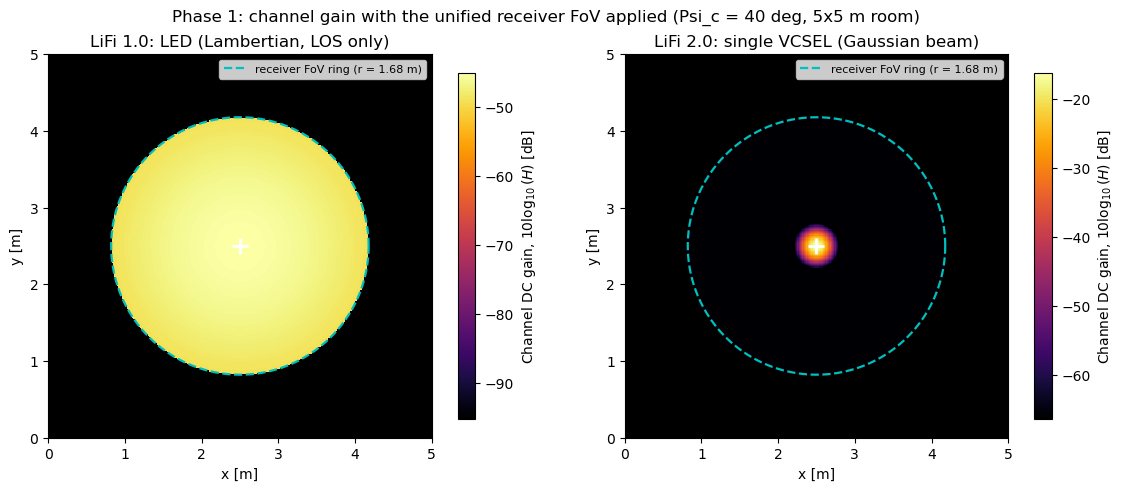

In [6]:
def to_dB(H):
    # channel gain in dB
    with np.errstate(divide="ignore"):
        return np.where(H > 0, 10 * np.log10(H), np.nan)

H_led_dB = to_dB(H_led)
H_vcsel_dB = to_dB(H_vcsel)

cmap = plt.cm.inferno.copy()
cmap.set_bad("black")  # NaN (outside the receiver FoV) rendered as true black

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8), constrained_layout=True)
maps = [(H_led_dB,   "LiFi 1.0: LED (Lambertian, LOS only)"),
        (H_vcsel_dB, "LiFi 2.0: single VCSEL (Gaussian beam)")]
th = np.linspace(0, 2 * np.pi, 200)
for ax, (H_dB, title) in zip(axes, maps):
    vmax = np.nanmax(H_dB)
    im = ax.pcolormesh(X, Y, H_dB, shading="auto", cmap=cmap, vmin=vmax - 50, vmax=vmax)
    ax.plot(TX_POS[0] + r_fov * np.cos(th), TX_POS[1] + r_fov * np.sin(th),
            "c--", lw=1.6, label=f"receiver FoV ring (r = {r_fov:.2f} m)")
    ax.plot(*TX_POS[:2], "w+", markersize=12, mew=2)
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.set_xlim(0, ROOM_X)
    ax.set_ylim(0, ROOM_Y)
    ax.legend(loc="upper right", fontsize=8)
    fig.colorbar(im, ax=ax, label=r"Channel DC gain, $10\log_{10}(H)$ [dB]", shrink=0.9)
fig.suptitle("Phase 1: channel gain with the unified receiver FoV applied "
             f"(Psi_c = {PSI_C_DEG:.0f} deg, {ROOM_X:.0f}x{ROOM_Y:.0f} m room)")
plt.show()

### 3.4 Channel gain vs. horizontal distance

This plot shows the exact same channel gain, but sliced along a straight line moving outward from directly under the transmitter, making it much easier to compare the LED and VCSEL shapes. 

* **Thin, faded lines:** Show the raw, source-only gain (from Section 3.2).
* **Solid lines:** Include the full receiver model, adding both the concentrator gain and the FoV cut-off (from Section 3.3).

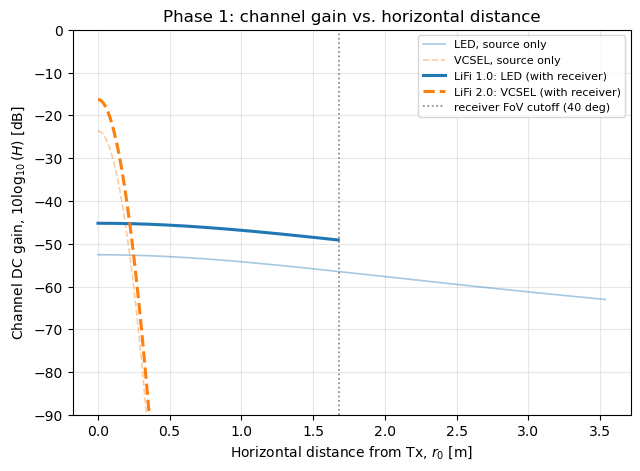

In [7]:
r0_line = np.linspace(1e-3, np.hypot(ROOM_X, ROOM_Y) / 2, 400)  # horizontal distance samples [m]
d_line = np.sqrt(r0_line**2 + dz**2)  # straight-line tx-rx distance along that line [m]
th_line = np.arctan2(r0_line, dz) # incidence angle along that line [rad]

# source-only gains along the line (same formulas as Section 3.2)
Hl_src_line = (m_led + 1) * APD / (2 * np.pi * d_line**2) * np.cos(th_line)**m_led * np.cos(th_line)
wz_line = W0 * np.sqrt(1 + (d_line / zR)**2)  # VCSEL beam radius along the line [m]
Hv_src_line = 2 / (np.pi * wz_line**2) * np.exp(-2 * r0_line**2 / wz_line**2) * APD

# receiver applied: concentrator gain inside the FoV, NaN outside so it just doesn't plot
Hl_line = np.where(th_line <= PSI_C, Hl_src_line * G_CONC, np.nan)
Hv_line = np.where(th_line <= PSI_C, Hv_src_line * G_CONC, np.nan)

fig, ax = plt.subplots(figsize=(7.2, 5))
ax.plot(r0_line, 10 * np.log10(Hl_src_line), color="tab:blue", lw=1.2, alpha=0.4, label="LED, source only")
ax.plot(r0_line, 10 * np.log10(Hv_src_line), color="tab:orange", lw=1.2, alpha=0.4, ls="--", label="VCSEL, source only")
ax.plot(r0_line, 10 * np.log10(Hl_line), color="tab:blue", lw=2.2, label="LiFi 1.0: LED (with receiver)")
ax.plot(r0_line, 10 * np.log10(Hv_line), color="tab:orange", lw=2.2, ls="--", label="LiFi 2.0: VCSEL (with receiver)")
ax.axvline(r_fov, color="gray", ls=":", lw=1.2, label=f"receiver FoV cutoff ({PSI_C_DEG:.0f} deg)")
ax.set_xlabel(r"Horizontal distance from Tx, $r_0$ [m]")
ax.set_ylabel(r"Channel DC gain, $10\log_{10}(H)$ [dB]")
ax.set_title("Phase 1: channel gain vs. horizontal distance")
ax.legend(fontsize=8)
ax.grid(alpha=.3)
ax.set_ylim(-90, 0)
plt.show()

Same room, same Tx/Rx geometry, and the same receiver FoV disk (Section 3.1) for both technologies, only the transmitter's own footprint on the desk plane differs. The LED's Lambertian lobe reaches all the way to the FoV disk edge; the VCSEL's Gaussian beam lands in a spot only about 12 cm in radius, nested well inside that same disk. This directivity gap is the starting point for every comparison in this notebook.

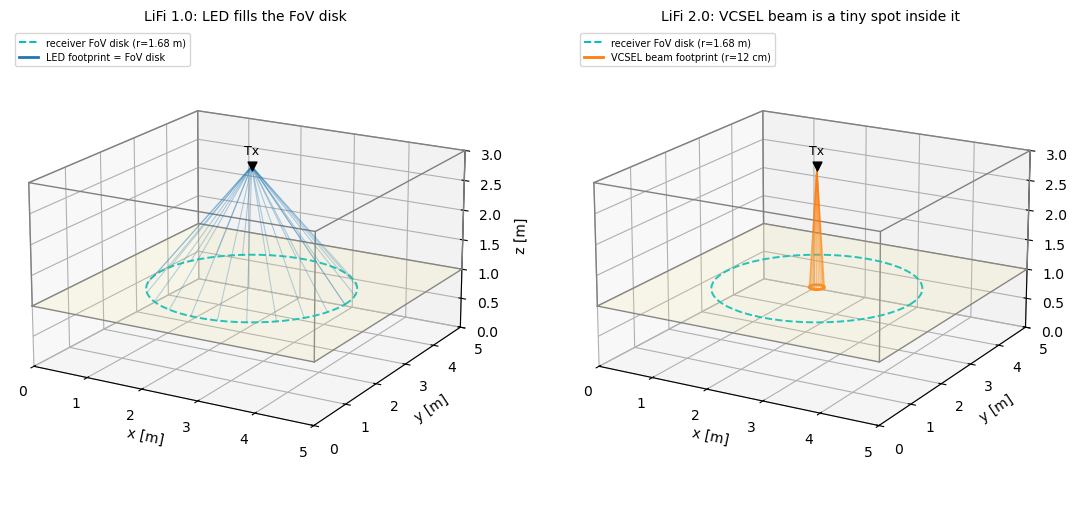

In [8]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (registers the 3D projection)

wz_boresight = W0 * np.sqrt(1 + (dz / zR)**2)  # VCSEL beam radius at the desk plane [m]


def draw_scenario(ax, footprint_radius, color, footprint_label, title, draw_own_circle=True):
    # room wireframe box
    for z in (RX_HEIGHT, TX_HEIGHT):
        ax.plot([0, ROOM_X, ROOM_X, 0, 0], [0, 0, ROOM_Y, ROOM_Y, 0], [z] * 5, color="gray", lw=1)
    for x in (0, ROOM_X):
        for y in (0, ROOM_Y):
            ax.plot([x, x], [y, y], [RX_HEIGHT, TX_HEIGHT], color="gray", lw=1)

    # desk plane
    xx, yy = np.meshgrid([0, ROOM_X], [0, ROOM_Y])
    ax.plot_surface(xx, yy, np.full_like(xx, RX_HEIGHT, dtype=float), color="khaki", alpha=0.15, shade=False)

    # Tx marker
    ax.scatter(*TX_POS, color="black", s=40, marker="v")
    ax.text(TX_POS[0], TX_POS[1], TX_POS[2] + 0.2, "Tx", fontsize=9, ha="center")

    # shared receiver FoV disk
    th = np.linspace(0, 2 * np.pi, 60)
    ax.plot(TX_POS[0] + r_fov * np.cos(th), TX_POS[1] + r_fov * np.sin(th), RX_HEIGHT,
            "c--", lw=1.4, label=f"receiver FoV disk (r={r_fov:.2f} m)")

    # transmitter footprint: rays from Tx to the footprint edge, on the desk plane
    for a in np.linspace(0, 2 * np.pi, 24):
        ax.plot([TX_POS[0], TX_POS[0] + footprint_radius * np.cos(a)],
                [TX_POS[1], TX_POS[1] + footprint_radius * np.sin(a)],
                [TX_POS[2], RX_HEIGHT], color=color, alpha=0.35, lw=0.8)
    if draw_own_circle:
        ax.plot(TX_POS[0] + footprint_radius * np.cos(th), TX_POS[1] + footprint_radius * np.sin(th), RX_HEIGHT,
                color=color, lw=2, label=footprint_label)
    else:
        ax.plot([], [], color=color, lw=2, label=footprint_label)  # legend entry only

    ax.set_xlim(0, ROOM_X)
    ax.set_ylim(0, ROOM_Y)
    ax.set_zlim(0, TX_HEIGHT)
    ax.set_box_aspect((ROOM_X, ROOM_Y, TX_HEIGHT))
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_zlabel("z [m]")
    ax.set_title(title, fontsize=10)
    ax.view_init(elev=18, azim=-60)
    ax.legend(loc="upper left", fontsize=7)


fig = plt.figure(figsize=(11.5, 5.2))

ax1 = fig.add_subplot(1, 2, 1, projection="3d")
draw_scenario(ax1, r_fov, "tab:blue", "LED footprint = FoV disk",
              "LiFi 1.0: LED fills the FoV disk", draw_own_circle=False)

ax2 = fig.add_subplot(1, 2, 2, projection="3d")
draw_scenario(ax2, wz_boresight, "tab:orange", f"VCSEL beam footprint (r={wz_boresight * 100:.0f} cm)",
              "LiFi 2.0: VCSEL beam is a tiny spot inside it")

plt.tight_layout()
plt.show()

### 3.5 Received power, SNR and achievable rate at the normalization power

For a transmit power $P_{tx}$, the received electrical SNR is (`[RIS-VLC]` eq. (12)):

$$\mathrm{SNR} = \frac{(\rho\,P_{r})^2}{N_0\,B}, \qquad P_r = P_{tx}\,H$$

The achievable rate is computed using

$$
R=\frac{B}{2}\log_2\left(1+\frac{e}{2\pi}\mathrm{SNR}\right),
$$

which is the lower bound commonly used for IM/DD (intensity-modulation, direct-detection) systems, from `[Capacity-Bound]`. Both `[RIS-VLC]` and `[VCSEL-Precoding]` use this expression instead of the classical Shannon capacity because optical wireless communication uses intensity modulation with non-negative signals, making the standard Shannon expression less appropriate.

For the noise, we assume the same PSD $N_0$ for both technologies. The `[RIS-VLC]` paper gives a value for $N_0$, `[VCSEL-Precoding]` doesn't, so I reuse the same one for the VCSEL under the assumption that the receiver itself doesn't change. This way any difference in the results comes from the transmitter and the channel, not from an arbitrary noise choice. Even with the same $N_0$, the total noise power still differs between the two because the bandwidth is different (20 MHz for LiFi 1.0, 2 GHz for LiFi 2.0).

This is a simplification since a GHz-class receiver wouldn't really share the exact same noise characteristics as one built for a few tens of MHz; but keeping $N_0$ fixed allows to isolate the effect of the propagation model, which is the actual point of this first part.


In [9]:
N0 = 2.5e-20   # noise PSD N0 [W/Hz], [RIS-VLC] (reused for LiFi 2.0)
B1 = 20e6      # LiFi 1.0 bandwidth [Hz], [RIS-VLC] Table III
B2 = 2e9       # LiFi 2.0 bandwidth [Hz], [VCSEL-Precoding] Table I

K_BOUND = np.e / (2 * np.pi)  # constant e/(2*pi) in the rate bound, [Capacity-Bound] eq. (37)

def snr_rate(Ptx_led, Ptx_vcsel):
    Pr_led = Ptx_led * H_led # received optical power, LED [W]
    Pr_vcsel = Ptx_vcsel * H_vcsel # received optical power, VCSEL [W]
    SNR_led = (RHO * Pr_led)**2 / (N0 * B1)   
    SNR_vcsel = (RHO * Pr_vcsel)**2 / (N0 * B2)
    # achievable-rate lower bound R = (B/2)*log2(1 + (e/2pi)*SNR), [Capacity-Bound] eq. (37)
    R_led = 0.5 * B1 * np.log2(1 + K_BOUND * SNR_led)   # [bit/s]
    R_vcsel = 0.5 * B2 * np.log2(1 + K_BOUND * SNR_vcsel) # [bit/s]
    return Pr_led, Pr_vcsel, SNR_led, SNR_vcsel, R_led, R_vcsel

PTX_NORM = 1.0  # normalization power for Phase 1 [W], same for both transmitters
Pr_led1, Pr_vcsel1, SNR_led1, SNR_vcsel1, R_led1, R_vcsel1 = snr_rate(PTX_NORM, PTX_NORM)

print(f"Phase 1 @ Ptx = {PTX_NORM:.0f} W (both):")
print(f"  LiFi 1.0: peak Pr={np.nanmax(Pr_led1)*1e3:.3f} mW, peak SNR={10*np.log10(np.nanmax(SNR_led1)):.1f} dB "
      f", peak rate={np.nanmax(R_led1)/1e6:.1f} Mbit/s")
print(f"  LiFi 2.0: peak Pr={np.nanmax(Pr_vcsel1)*1e3:.3f} mW, peak SNR={10*np.log10(np.nanmax(SNR_vcsel1)):.1f} dB "
      f", peak rate={np.nanmax(R_vcsel1)/1e6:.1f} Mbit/s")


Phase 1 @ Ptx = 1 W (both):
  LiFi 1.0: peak Pr=0.030 mW, peak SNR=32.6 dB , peak rate=96.3 Mbit/s
  LiFi 2.0: peak Pr=23.246 mW, peak SNR=70.3 dB , peak rate=22156.7 Mbit/s


### 3.6 Coverage vs. SNR threshold

Instead of picking one SNR threshold and reporting a single coverage number, I sweep the threshold and plot the whole curve to show a lot more about how the two channels behave. First both curves together on the same axis, to see them at a glance; then each technology on its own plot, with its own y-scale, since the VCSEL's coverage values are about two orders of magnitude smaller than the LED's (Section 3.1-3.5 already show why) -- on the shared axis its curve is barely visible above $y=0$.

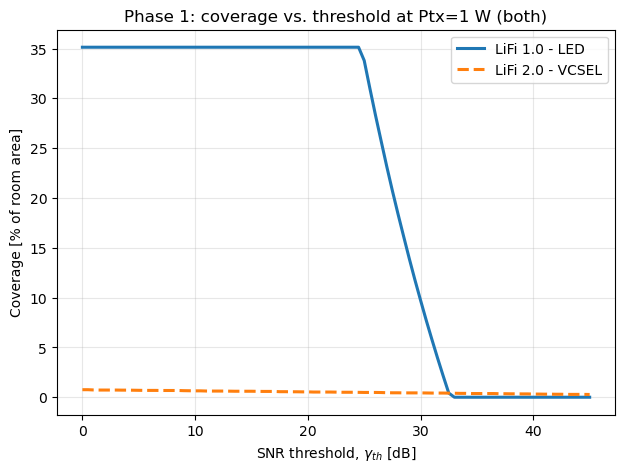

In [10]:
th_range_dB = np.linspace(0, 45, 91)  # SNR thresholds to sweep [dB]
cov_led_curve, cov_vcsel_curve = [], []
for th_dB in th_range_dB:
    g = 10**(th_dB / 10)  # threshold converted to linear scale
    cov_led_curve.append(100 * np.mean(SNR_led1 >= g))      # % of room area above threshold, LED
    cov_vcsel_curve.append(100 * np.mean(SNR_vcsel1 >= g))  # % of room area above threshold, VCSEL

fig, ax = plt.subplots(figsize=(7.2, 5))
ax.plot(th_range_dB, cov_led_curve, lw=2.2, label="LiFi 1.0 - LED")
ax.plot(th_range_dB, cov_vcsel_curve, lw=2.2, ls="--", label="LiFi 2.0 - VCSEL")
ax.set_xlabel(r"SNR threshold, $\gamma_{th}$ [dB]")
ax.set_ylabel("Coverage [% of room area]")
ax.set_title(f"Phase 1: coverage vs. threshold at Ptx={PTX_NORM:.0f} W (both)")
ax.legend()
ax.grid(alpha=.3)
plt.show()

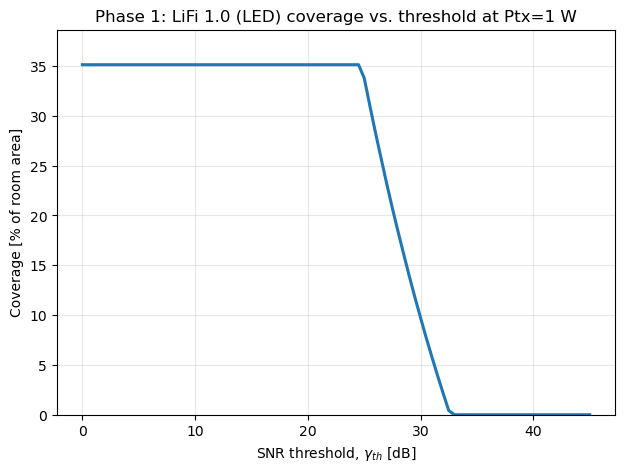

In [11]:
# same data, LiFi 1.0 alone, on its own representative scale
fig, ax = plt.subplots(figsize=(7.2, 5))
ax.plot(th_range_dB, cov_led_curve, lw=2.2, color="tab:blue")
ax.set_xlabel(r"SNR threshold, $\gamma_{th}$ [dB]")
ax.set_ylabel("Coverage [% of room area]")
ax.set_title(f"Phase 1: LiFi 1.0 (LED) coverage vs. threshold at Ptx={PTX_NORM:.0f} W")
ax.set_ylim(0, max(cov_led_curve) * 1.1)
ax.grid(alpha=.3)
plt.show()

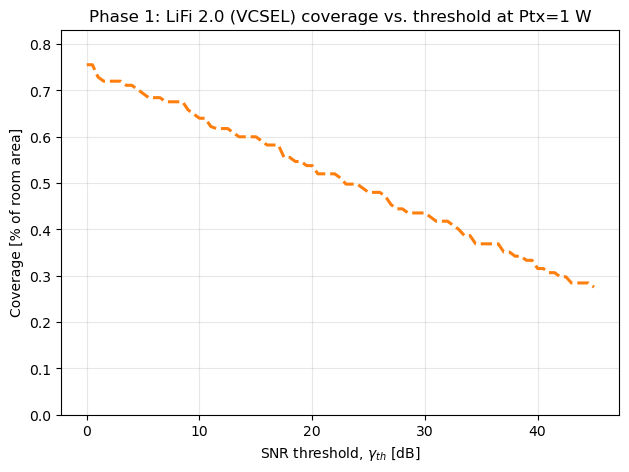

In [12]:
# same sweep, LiFi 2.0 alone -- its own scale is roughly 100x smaller than
# the LED's, so sharing one axis with the plot above would flatten this to
# a near-invisible line along y=0
fig, ax = plt.subplots(figsize=(7.2, 5))
ax.plot(th_range_dB, cov_vcsel_curve, lw=2.2, color="tab:orange", ls="--")
ax.set_xlabel(r"SNR threshold, $\gamma_{th}$ [dB]")
ax.set_ylabel("Coverage [% of room area]")
ax.set_title(f"Phase 1: LiFi 2.0 (VCSEL) coverage vs. threshold at Ptx={PTX_NORM:.0f} W")
ax.set_ylim(0, max(cov_vcsel_curve) * 1.1)
ax.grid(alpha=.3)
plt.show()

In [13]:
diff = np.array(cov_vcsel_curve) - np.array(cov_led_curve)
sign_changes = np.where(np.diff(np.sign(diff)) != 0)[0]

print("Crossing point(s) between the LED and VCSEL coverage-vs-threshold curves:")
for idx in sign_changes:
    if max(cov_led_curve[idx + 1], cov_vcsel_curve[idx + 1]) < 0.1:
        continue  # not a real crossing, both curves are already at zero coverage
    th1, th2 = th_range_dB[idx], th_range_dB[idx + 1]
    d1, d2 = diff[idx], diff[idx + 1]
    th_cross = th1 - d1 * (th2 - th1) / (d2 - d1)
    print(f"  ~{th_cross:4.1f} dB  (LED~{cov_led_curve[idx]:.1f}%, VCSEL~{cov_vcsel_curve[idx]:.1f}%)")

fov_disk_pct = 100 * np.pi * r_fov**2 / (ROOM_X * ROOM_Y)
print(f"\nShared FoV-disk geometric max coverage: {fov_disk_pct:5.1f}% of the room "
      "(both curves saturate at this value at low thresholds)")

# SNR at the FoV-disk edge @1W: 
d_edge = np.hypot(r_fov, dz)
Hl_edge = (m_led + 1) * APD / (2 * np.pi * d_edge**2) * np.cos(PSI_C)**m_led * np.cos(PSI_C) * G_CONC
wz_edge = W0 * np.sqrt(1 + (d_edge / zR)**2)
Hv_edge = 2 / (np.pi * wz_edge**2) * np.exp(-2 * r_fov**2 / wz_edge**2) * APD * G_CONC
vcsel_edge_snr_dB = 10*np.log10((RHO*Hv_edge)**2/(N0*B2))
print(f"SNR at the FoV-disk edge @ 1 W: LED = {10*np.log10((RHO*Hl_edge)**2/(N0*B1)):.1f} dB, "
      f"VCSEL = negligible ({vcsel_edge_snr_dB:.0f} dB, floating-point noise, not a real SNR)"
      if vcsel_edge_snr_dB < -100 else f"VCSEL = {vcsel_edge_snr_dB:.1f} dB")

Crossing point(s) between the LED and VCSEL coverage-vs-threshold curves:
  ~32.5 dB  (LED~0.4%, VCSEL~0.4%)

Shared FoV-disk geometric max coverage:  35.4% of the room (both curves saturate at this value at low thresholds)
SNR at the FoV-disk edge @ 1 W: LED = 24.8 dB, VCSEL = negligible (-1896 dB, floating-point noise, not a real SNR)


This shows how much of the room floor clears each possible quality bar. The LED starts at the FoV-disk maximum and holds it until the threshold gets demanding. The VCSEL never gets close to that maximum in the first place, since its own beam width, not the receiver's FoV, is what limits it (but the small area it does cover stays lit across a much wider range of thresholds, simply because its peak signal is so much stronger).

### 3.7 Phase 1 discussion

* **The LED covers its entire ~35% FoV-disk plateau at low thresholds, and only starts losing area past about 25 dB** (falling to half that area by ~28.5 dB). Its flat Lambertian pattern is what keeps the whole disk covered up to such demanding thresholds.

* **The VCSEL does not reach that 35% plateau at any threshold tested here: even at a 0 dB threshold, its coverage is only about 0.8% of the room.** Its own beam (about 12 cm in radius at the desk) is far narrower than the 1.68 m FoV disk, so the receiver's field of view is not what limits the VCSEL here - its own directivity is. That tiny covered area barely shrinks as the threshold rises (0.8% at 0 dB, still 0.3% at 40 dB), because the signal right at the beam axis is so strong that only extreme thresholds can knock it out.

* **The VCSEL's peak SNR (~70 dB) is now far above the LED's (~33 dB), and so is its peak channel gain (about 29 dB more at the center).** Concentrating the same 1 W into a beam only centimetres wide, instead of spreading it Lambertian-style across the room, is what buys that gain. Even after the VCSEL's 100x larger bandwidth adds 20 dB of extra noise power, its SNR advantage survives, and it converts into a peak rate of about 22 Gbit/s against the LED's 96 Mbit/s -- roughly 230x faster, at the one point where the VCSEL's beam actually lands.

**Phase 1 conclusion.** At equal power, the two technologies split the problem in opposite directions: the LED trades peak signal strength for area, covering over a third of the room at a modest rate everywhere within it; the VCSEL trades area for peak signal strength, delivering an extreme rate but only in a spot about the size of a small dinner plate. Neither number is "better" alone, since which one matters depends entirely on whether the goal is area or a point.

---

## 4. Phase 2: Realistic single-cell analysis

Here the question changes. Phase 1 asked "how do the channels compare", Phase 2 asks "what actually happens once each technology is limited by its own real constraints." So instead of the arbitrary 1 W for both, each transmitter now gets the power it should use in real life. 


### 4.1 LiFi 1.0 power - illuminance requirement

The LED power is obtained from an illuminance target: 500 lux, the EN 12464-1 value for office reading/writing tasks (also used in `[RIS-VLC]` Sec. V). EN 12464-1 sets this target over the **task area** (the actual desk/work surface) not necessarily the whole room. `[RIS-VLC]`'s own benchmark averages over the whole room because several LEDs cooperate there, but a single, isolated LED standing in for one attocell (the small coverage area served by a single AP) shouldn't have to light an entire 25 m² floor by itself. So here the target is averaged over a 1 m x 1 m desk-sized task area centered directly under the Tx instead:

$$\overline{E_v} = \frac{K_{e/v}}{A_{PD}}\,P_{tx}\,\overline{H_{LED}^{task}} \quad\Rightarrow\quad P_{tx} = \frac{E_{target}}{(K_{e/v}/A_{PD})\,\overline{H_{LED}^{task}}}$$

where $\overline{H_{LED}^{task}}$ is $H_{LED}$ (Section 3.1, source-only) averaged over that task area, and $A_{PD}$ cancels out as before, since illuminance describes the light field itself, not a particular detector.

In [14]:
KE_V = 280.0          # luminous efficacy K_e/v [lm/W], [RIS-VLC] Table III
E_TARGET_LUX = 500.0  # illuminance target [lux], EN 12464-1 task-area value for office work ([RIS-VLC] Sec. V)

# Illuminance from optical power, [RIS-VLC] eq. (25): E_v = (K_e/v / A_PD) * P * H_LoS

# EN 12464-1 defines the 500 lux target over the task area, not the whole room. A single,
# isolated LED here stands in for one desk-sized cell, so the target is averaged over a
# 1x1 m task area centered under the Tx -- not the whole 5x5 m floor, which is only
# realistic once several LEDs cooperate (as in [RIS-VLC]'s own multi-LED benchmark, or
# in the multi-cell notebook).

TASK_HALF = 0.5  # task-area half-width [m] -> a 1 m x 1 m desk-sized footprint
task_mask = (np.abs(X - TX_POS[0]) <= TASK_HALF) & (np.abs(Y - TX_POS[1]) <= TASK_HALF)

E_per_watt_task = KE_V * np.mean(H_led_src[task_mask]) / APD  # average lux per watt, over the task area
PTX_LED_REALISTIC = E_TARGET_LUX / E_per_watt_task  # LED power for the 500 lux task-area target [W]
print(f"LiFi 1.0 realistic power (single LED, {E_TARGET_LUX:.0f} lux averaged over a "
      f"{2 * TASK_HALF:.0f}x{2 * TASK_HALF:.0f} m task area): {PTX_LED_REALISTIC:.1f} W")

LiFi 1.0 realistic power (single LED, 500 lux averaged over a 1x1 m task area): 34.4 W


### 4.2 LiFi 2.0 power - eye safety IEC 60825-1

For the VCSEL, the transmit power is limited by eye-safety requirements.

Unlike LEDs, VCSELs are laser sources, meaning that the maximum optical power of a single emitter is constrained by the IEC 60825-1 laser safety standard. Consequently, a single VCSEL cannot operate at the same optical power as a LED.

To obtain a realistic value, the maximum eye-safe power is estimated following the methodology presented in `[Eye-Safety]`.

Following `[Eye-Safety]`, the point-source Maximum Permissible Exposure (IEC 60825-1, near-IR, long exposure) is:

$$\text{MPE}(\lambda) = 10\,C_4\,C_7 \ \ [\text{W/m}^2], \qquad C_4=10^{0.002(\lambda-700)}, \qquad C_7=\begin{cases}1, & \lambda < 1150\ nm \\ 10^{0.018(\lambda-1150)}, & \lambda \geq 1150\ nm\end{cases}$$

$C_4$ and $C_7$ are wavelength-correction factors the standard uses to scale a single baseline exposure limit (10 W/m$^2$, defined at 700 nm) across the near-infrared band, instead of giving one MPE value per wavelength directly: $C_4$ raises the permissible exposure as the wavelength grows from 700 nm towards about 1050-1150 nm, since the retina absorbs somewhat less energy per watt in that range; $C_7$ raises it further only beyond 1150 nm, once the eye's own anterior media (cornea, lens) start absorbing enough of the light that less of it reaches the retina in the first place. At the VCSEL's $\lambda=950$ nm, only $C_4$ is active ($C_7=1$): the correction that matters here is purely the retinal one.

The maximum eye-safe CW power of a single-mode Gaussian beam is then (`[Eye-Safety]` eq. (36)):

$$P_{tx,max} = \frac{1}{\eta}\,\text{MPE}(\lambda)\,\pi r_p^2$$

where $\eta$ is the fraction of the beam's power that could enter a dilated pupil of radius $r_p$ at the hazard distance $z_{haz}$ (see Section 4.2.1 for the caveats on this estimate).

#### 4.2.1 Choosing a physically consistent beam waist

The beam waist $w_0$ is not only used for the eye-safety ceiling below: it sets the Rayleigh range $z_R$ and the beam radius $w(d)$ in the VCSEL channel model (Section 3.1), which feeds every VCSEL channel-gain map, SNR value and coverage number in this notebook, in both Phase 1 and Phase 2. It has to be chosen once, deliberately, rather than picked up implicitly wherever it first appears.

`[VCSEL-Precoding]` Table I lists $w_0 = 0.45\ \mu m$, but that value is smaller than the VCSEL's own wavelength $\lambda = 950\ nm$. The Gaussian-beam model used throughout this notebook requires $w_0 \gg \lambda$ (the paraxial regime), so $0.45\ \mu m$ sits outside where the model is actually valid: it gives an unrealistically large divergence, $\theta \approx \lambda/(\pi w_0) \approx 38°$ half-angle, far wider than a real VCSEL beam.

This notebook instead uses $w_0 = 5\ \mu m$ as the primary value everywhere, the same realistic waist that `[Eye-Safety]` itself uses in its own worked examples (Figs. 7, 9, 13, 16-18) - this is the same choice already used in the multi-cell notebook, for consistency between the two. At this value $w_0 \gg \lambda$ holds comfortably, the divergence half-angle drops to a physically reasonable $\theta \approx 3.5°$, and, as the next cell shows, the resulting eye-safe ceiling comes out close to the $5\ mW$ experimentally reported in `[VCSEL-70Gbps]`, instead of 45x above it.

The sub-wavelength $0.45\ \mu m$ value is not discarded, since it is what `[VCSEL-Precoding]` itself reports: Section 4.2.2 keeps it as an idealized sensitivity case, to check how much this notebook's conclusions actually depend on the choice of $w_0$.

In [15]:
def mpe_point_long_exposure(lam_nm):
    # IEC 60825-1 point-source MPE, near-IR, long exposure (t_ex > 10 s)
    # [Eye-Safety] Table 4:  MPE = 10 * C4 * C7 [W/m^2];  C4 = 10^(0.002(lam-700));  C7 = 1 for lam < 1150 nm
    C4 = 10**(0.002 * (lam_nm - 700))
    C7 = 1.0 if lam_nm < 1150 else 10**(0.018 * (lam_nm - 1150))
    return 10 * C4 * C7  # MPE [W/m^2]

assert abs(mpe_point_long_exposure(850) - 19.95) < 0.1  # [Eye-Safety]: ~20 W/m^2 at 850 nm (matches the tutorial)
MPE_950 = mpe_point_long_exposure(950)

def eye_safe_ptx(w0, lam, rp=3.5e-3):
    # max eye-safe CW power for a single-mode Gaussian VCSEL beam, [Eye-Safety] Algorithm 1 + eq. (36)
    # w0: beam waist [m], lam: wavelength [m], rp: worst-case dilated pupil radius [m]
    # rp = 3.5 mm -> 7 mm limiting aperture ([Eye-Safety] Sec. II-D)

    zR_ = np.pi * w0**2 / lam       # Rayleigh range, [VCSEL-Precoding] eq. (2) / [Eye-Safety] eq. (5)
    theta_div = lam / (np.pi * w0)  # beam divergence half-angle, [Eye-Safety] eq. (8)
    d86 = (np.pi * w0 / lam) * np.sqrt(-2 * rp**2 / np.log(1 - 0.86))  # distance where the pupil catches 86% of the beam power [m]
    # [Eye-Safety] Algorithm 1, step 1
    if 2 * theta_div > 0.092 and d86 < 0.1:
        zhaz = 0.1  # hazard distance capped at 10 cm for wide-divergence beams ([Eye-Safety] Alg. 1)
    else:
        alpha = 2 * np.arctan(w0 / d86)
        zhaz = 2 * w0 / 0.0021 if alpha < 1.5e-3 else 9.2 * np.pi * w0 / (2 * lam)  # [Eye-Safety] Alg. 1, step 9/12
    Wzhaz = w0 * np.sqrt(1 + (zhaz / zR_)**2)  # beam radius at the hazard distance, [Eye-Safety] eq. (4a)
    eta = 1 - np.exp(-2 * rp**2 / Wzhaz**2)    # fraction of beam power entering the pupil
    return (1 / eta) * mpe_point_long_exposure(lam * 1e9) * np.pi * rp**2, zhaz, eta  # Pt,max, [Eye-Safety] eq. (36)

PTX_VCSEL_EYESAFE, _, _ = eye_safe_ptx(W0, LAMBDA)  # hazard distance/pupil fraction not needed beyond this point
PTX_VCSEL_EXPERIMENTAL = 5e-3  # [VCSEL-70Gbps] Table I (Pt = 4.26 / 4.95 mW) / abstract ("below 5 mW"), 940 nm -- literature cross-check only, not used in any computation below

print(f"MPE(950nm, point source, long exposure) = {MPE_950:.1f} W/m^2")
print(f"Eye-safe ceiling (single bare VCSEL, w0={W0*1e6:.2f} um, IEC 60825-1): {PTX_VCSEL_EYESAFE*1e3:.2f} mW "
      f"-- the value used throughout this notebook.")
print(f"For context only: a real VCSEL device reported in the literature ([VCSEL-70Gbps], Kazemi et al. 2025) "
      f"operates at about {PTX_VCSEL_EXPERIMENTAL*1e3:.0f} mW, the same order of magnitude -- confirming this "
      f"ceiling is a physically realistic number, not just a theoretical one.")
print(f"\nRatio LED/VCSEL realistic power: {PTX_LED_REALISTIC/PTX_VCSEL_EYESAFE:.0f}x")

MPE(950nm, point source, long exposure) = 31.6 W/m^2
Eye-safe ceiling (single bare VCSEL, w0=5.00 um, IEC 60825-1): 2.49 mW -- the value used throughout this notebook.
For context only: a real VCSEL device reported in the literature ([VCSEL-70Gbps], Kazemi et al. 2025) operates at about 5 mW, the same order of magnitude -- confirming this ceiling is a physically realistic number, not just a theoretical one.

Ratio LED/VCSEL realistic power: 13809x


#### 4.2.2 Sensitivity to the beam waist

$w_0 = 5\ \mu m$ is used as the primary value throughout this notebook (Section 4.2.1), but it is worth checking how much the conclusions would change with a different, idealized waist instead -- in particular the sub-wavelength $0.45\ \mu m$ that `[VCSEL-Precoding]` Table I literally states, kept here only as a sensitivity case rather than as the notebook's main configuration.

As a further data point, `[VCSEL-70Gbps]` reports a measured divergence half-angle (defined at the 86%-power beam radius) of $12.7°\text{-}15.3°$; using the midpoint $\theta\approx14°$ and inverting $\theta\approx\lambda/(\pi w_0)$ gives a third, experimentally-grounded waist,

$$w_{0,\text{alt}} = \frac{\lambda}{\pi\theta} \approx 1.24\ \mu m.$$

This mixes two different divergence-angle definitions (the 86%-power one reported experimentally vs. the $1/e^2$ Gaussian one used by the model), so it is only an order-of-magnitude cross-check, not a substitute for the primary $5\ \mu m$ value.

In [16]:
# sensitivity check: eye-safe Ptx and Phase-2 peak SNR at the three waists discussed above
import pandas as pd

THETA_DIV_EXP_DEG = 14.0  # [VCSEL-70Gbps]: midpoint of the reported 12.7-15.3 deg range
W0_ALT = LAMBDA / (np.pi * np.deg2rad(THETA_DIV_EXP_DEG))  # inverting theta = lambda/(pi*w0)


def vcsel_channel(w0):
    # same Section 3.1 formulas, recomputed for a different w0 only
    zR_ = np.pi * w0**2 / LAMBDA
    wz_ = w0 * np.sqrt(1 + (d3d / zR_)**2)
    H_src = 2 / (np.pi * wz_**2) * np.exp(-2 * r0**2 / wz_**2) * APD
    return np.where(in_fov, H_src * G_CONC, 0.0)


waist_cases = [
    ("0.45 um - [VCSEL-Precoding] Table I (sub-wavelength, rejected)", 0.45e-6),
    (f"{W0_ALT * 1e6:.2f} um - [VCSEL-70Gbps]-derived divergence (cross-check)", W0_ALT),
    ("5 um - chosen, value used throughout this notebook", 5e-6),
]

rows = []
for label, w0_case in waist_cases:
    Ptx_case, _, _ = eye_safe_ptx(w0_case, LAMBDA)
    H_case = vcsel_channel(w0_case)
    peak_snr_case_dB = 10 * np.log10(np.nanmax((RHO * Ptx_case * H_case)**2 / (N0 * B2)))
    rows.append({"Beam waist w0": label, "Eye-safe Ptx": f"{Ptx_case * 1e3:.2f} mW",
                 "Phase-2 peak SNR": f"{peak_snr_case_dB:.1f} dB"})
pd.DataFrame(rows)

,Beam waist w0,Eye-safe Ptx,Phase-2 peak SNR
0,0.45 um - [VCSEL-Precoding] Table I (sub-wavel...,224.92 mW,15.7 dB
1,1.24 um - [VCSEL-70Gbps]-derived divergence (c...,30.27 mW,15.9 dB
2,"5 um - chosen, value used throughout this note...",2.49 mW,18.3 dB


The table above compares the eye-safe ceiling and the resulting Phase-2 peak SNR at the three waists discussed. As the beam narrows, the eye-safe power rises but the peak SNR falls -- a narrower waist diverges faster, so it has already spread out more by the time it reaches the receiver. All three waists clear the 10 dB coverage threshold used throughout this notebook (though, per Section 4.2.2's own table, only barely for the two idealized ones -- 15.7 and 15.9 dB -- against 18.3 dB for the chosen 5 um waist).

**The value used everywhere in this project is $w_0 = 5\ \mu m \rightarrow P_{tx} = 2.49$ mW.** The other two rows are shown only to confirm that this conclusion does not depend on which literature value for $w_0$ is picked -- they are not alternative operating points.

In [17]:
Pr_led_re, Pr_vcsel_eyesafe, SNR_led_re, SNR_vcsel_eyesafe, R_led_re, R_vcsel_eyesafe = snr_rate(PTX_LED_REALISTIC, PTX_VCSEL_EYESAFE)

GAMMA_TH_DB = 10.0  # same threshold adopted in the multi-cell notebook, for consistency between the two
gamma_th = 10**(GAMMA_TH_DB / 10)

### 4.3 Spectral consideration - wavelength-dependent responsivity

Everywhere above both technologies use the same fixed responsivity $\rho = 1$ A/W, which is what isolates the channel and power effects. In reality the photodiode responsivity depends on the wavelength,

$$\rho(\lambda) = \eta\,\frac{q\,\lambda}{h\,c},$$

and for a silicon photodiode it grows with $\lambda$ up to the ~1100 nm cut-off. LiFi 1.0 emits across the visible band, while LiFi 2.0 emits in the near-IR (~950 nm), so at the same received optical power the VCSEL produces more photocurrent — the near-IR link benefits from the receiver's higher responsivity.

This is a receiver property, so it does not change any Phase 1/2 conclusion, but since $\text{SNR}\propto(\rho P_r)^2$ it does shift the SNR. I keep $\rho = 1$ as the baseline and only quantify the effect here with representative datasheet values.

In [18]:
Q_E = 1.602e-19    # electron charge [C]
H_PLANCK = 6.626e-34  # Planck constant [J*s]
C_LIGHT = 3e8      # speed of light [m/s]

def responsivity_ideal(lam_nm, qe=1.0):
    # ideal photodiode responsivity rho = qe*q*lambda/(h*c) [A/W]
    lam = lam_nm * 1e-9
    return qe * Q_E * lam / (H_PLANCK * C_LIGHT)

# representative silicon PIN photodiode values (datasheet-dependent)
RHO_LED = 0.4    # ~550 nm effective, visible band (LiFi 1.0) [A/W]
RHO_VCSEL = 0.6  # ~950 nm (LiFi 2.0) [A/W]

print(f"ideal rho (qe=1): @550nm = {responsivity_ideal(550):.2f} A/W, @950nm = {responsivity_ideal(950):.2f} A/W")
print(f"representative rho: LED (visible) = {RHO_LED} A/W, VCSEL (950 nm) = {RHO_VCSEL} A/W")

# effect on SNR: SNR ~ (rho*Pr)^2
d_snr_led_dB = 20 * np.log10(RHO_LED / RHO)
d_snr_vcsel_dB = 20 * np.log10(RHO_VCSEL / RHO)
net_shift_dB = d_snr_vcsel_dB - d_snr_led_dB
print(f"\nSNR shift vs the rho=1 baseline: LED {d_snr_led_dB:+.1f} dB, VCSEL {d_snr_vcsel_dB:+.1f} dB")
print(f"Net relative shift in favour of the VCSEL: {net_shift_dB:+.1f} dB")

# recompute Phase 2 coverage with the wavelength-dependent responsivities (same [RIS-VLC] eq. (12) SNR)
SNR_led_rho = (RHO_LED * PTX_LED_REALISTIC * H_led)**2 / (N0 * B1)
SNR_vcsel_rho = (RHO_VCSEL * PTX_VCSEL_EYESAFE * H_vcsel)**2 / (N0 * B2)
cov_led_re_rho1 = 100 * np.mean(SNR_led_re >= gamma_th)      # rho=1 baseline, for comparison below
cov_vcsel_re_rho1 = 100 * np.mean(SNR_vcsel_eyesafe >= gamma_th)
print(f"\nPhase 2 coverage @ {GAMMA_TH_DB:.0f} dB with wavelength-dependent rho:")
print(f"  LiFi 1.0 (rho={RHO_LED}):   {100*np.mean(SNR_led_rho >= gamma_th):.1f}%  (was {cov_led_re_rho1:.1f}% at rho=1)")
print(f"  LiFi 2.0 (rho={RHO_VCSEL}): {100*np.mean(SNR_vcsel_rho >= gamma_th):.1f}%  (was {cov_vcsel_re_rho1:.1f}% at rho=1)")
print(f"\n-> the {net_shift_dB:+.1f} dB relative gain for the VCSEL doesn't flip the picture: a single VCSEL is still power-limited.")

ideal rho (qe=1): @550nm = 0.44 A/W, @950nm = 0.77 A/W
representative rho: LED (visible) = 0.4 A/W, VCSEL (950 nm) = 0.6 A/W

SNR shift vs the rho=1 baseline: LED -8.0 dB, VCSEL -4.4 dB
Net relative shift in favour of the VCSEL: +3.5 dB

Phase 2 coverage @ 10 dB with wavelength-dependent rho:
  LiFi 1.0 (rho=0.4):   35.1%  (was 35.1% at rho=1)
  LiFi 2.0 (rho=0.6): 0.0%  (was 0.1% at rho=1)

-> the +3.5 dB relative gain for the VCSEL doesn't flip the picture: a single VCSEL is still power-limited.


### 4.4 Coverage under realistic power

Same maps as before (Section 3.6), now at $\gamma_{th}=10$ dB -- the same threshold adopted in the multi-cell notebook -- with each technology at its own realistic power (Sections 4.1-4.2) instead of the shared 1 W.

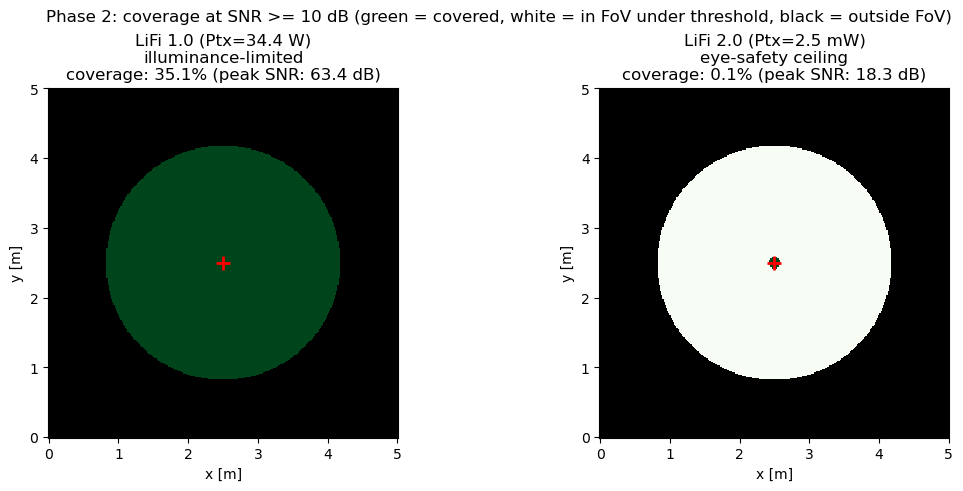

In [19]:
cov_led_re = SNR_led_re >= gamma_th # coverage map, LED at realistic power
cov_vcsel_eyesafe_map = SNR_vcsel_eyesafe >= gamma_th # coverage map, VCSEL at the eye-safety ceiling

cov_cmap = plt.cm.Greens.copy()
cov_cmap.set_bad("black")
# unified receiver: the same FoV mask (in_fov, from Section 3.1) applies to both technologies

def cov_black_outside(cov, in_fov):
    return np.where(in_fov, cov.astype(float), np.nan)

peak_snr_led_dB = 10 * np.log10(np.nanmax(SNR_led_re))
peak_snr_eyesafe_dB = 10 * np.log10(np.nanmax(SNR_vcsel_eyesafe))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), constrained_layout=True)
panels = [
    (cov_black_outside(cov_led_re, in_fov), cov_led_re, peak_snr_led_dB,
     f"LiFi 1.0 (Ptx={PTX_LED_REALISTIC:.1f} W)\nilluminance-limited"),
    (cov_black_outside(cov_vcsel_eyesafe_map, in_fov), cov_vcsel_eyesafe_map, peak_snr_eyesafe_dB,
     f"LiFi 2.0 (Ptx={PTX_VCSEL_EYESAFE * 1e3:.1f} mW)\neye-safety ceiling"),
]
for ax, (cov_disp, cov_bool, peak_snr_dB, title) in zip(axes, panels):
    ax.pcolormesh(X, Y, cov_disp, shading="auto", cmap=cov_cmap, vmin=0, vmax=1)
    ax.plot(*TX_POS[:2], "r+", markersize=10, mew=2)
    ax.set_title(f"{title}\ncoverage: {100 * cov_bool.mean():.1f}% (peak SNR: {peak_snr_dB:.1f} dB)")
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_aspect("equal")
fig.suptitle(f"Phase 2: coverage at SNR >= {GAMMA_TH_DB:.0f} dB "
             "(green = covered, white = in FoV under threshold, black = outside FoV)")
plt.show()

**Reading the maps:** green means good enough signal, white means in view but too weak, and black means the receiver can't see that area at all.

**Observation.** At realistic power, the LED covers just over a third of the room, essentially its whole FoV disk (Section 3.3). The VCSEL covers 0.09% of the room at its eye-safety ceiling -- its peak SNR (18.3 dB) does clear the 10 dB bar, but only in a sliver right at the beam axis, since its beam is only about 12 cm wide against a 1.68 m FoV disk.

**Why.** The LED's coverage is set by its FoV disk, not by its power (it already has enough SNR headroom everywhere inside that disk). The VCSEL's problem is different: even with enough power to clear the bar at its own axis, its narrow beam confines that clearance to a tiny spot, well short of the disk its receiver could otherwise see.

### 4.5 Summary and energy efficiency

This table puts every scenario computed so far side by side: Phase 1's shared, unrealistic 1 W (Section 3), and Phase 2's official, standards-grounded operating point for each technology (Sections 4.1-4.2) -- so the normalized-power and the realistic-power pictures can be read off the same table instead of two separate ones.

Energy efficiency, the achievable rate per watt of transmit power ($\text{EE}=R/P_{tx}$), and area spectral efficiency (ASE, $\text{ASE}=\overline{R}/A_{room}$, the same metric already used for a single AP in the multi-cell notebook) are added alongside peak SNR, peak rate, and coverage.

Only the Phase-2 rows are grounded in standards and literature: 500 lux over the task area (EN 12464-1), the IEC 60825-1 eye-safety ceiling, $\Psi_c=40°$ (a receiver design choice taken from `[RIS-VLC]`, Section 3.1), and $\gamma_{th}=10$ dB (the low end of the 10-50 dB range `[RIS-VLC]` associates with 2-256 PAM at BER $=10^{-6}$ in an IM/DD link, the same threshold adopted in the multi-cell notebook). Phase 1's 1 W is shown only as the equal-power reference point, not as an alternative realistic scenario.

In [20]:
import pandas as pd

def ee_peak_avg(rate_map, Ptx):
    # (peak, avg) energy efficiency in bit/J, from a rate map [bit/s] and Ptx [W]
    peak = np.nanmax(rate_map) / Ptx
    avg = np.nanmean(np.nan_to_num(rate_map, nan=0.0)) / Ptx
    return peak, avg

ROOM_AREA = ROOM_X * ROOM_Y  # [m^2]

def spatial_ase(rate_map):
    # area spectral efficiency [bit/s/m^2]: mean rate over the whole room (NaN, i.e. outside
    # the FoV, counts as zero), divided by room area -- same definition as N_AP=1 in the
    # multi-cell notebook, so single- and multi-cell ASE numbers are directly comparable
    return np.nanmean(np.nan_to_num(rate_map, nan=0.0)) / ROOM_AREA

def summary_row(scenario, Ptx_str, Ptx_for_ee, SNR_map, R_map):
    ee_peak, ee_avg = ee_peak_avg(R_map, Ptx_for_ee)
    return {
        "Scenario": scenario,
        "Transmit power": Ptx_str,
        "Peak SNR [dB]": round(10 * np.log10(np.nanmax(SNR_map)), 1),
        "Peak rate [Mbit/s]": round(np.nanmax(R_map) / 1e6, 1),
        f"Coverage @ {GAMMA_TH_DB:.0f} dB [%]": round(100 * np.mean(SNR_map >= gamma_th), 2),
        "ASE [Mbit/s/m2]": round(spatial_ase(R_map) / 1e6, 4),
        "EE peak [Mbit/J]": round(ee_peak / 1e6, 2),
        "EE avg [Mbit/J]": round(ee_avg / 1e6, 4),
    }

summary_df = pd.DataFrame([
    summary_row("LiFi 1.0 -- Phase 1 (normalized, 1 W)", f"{PTX_NORM:.0f} W", PTX_NORM, SNR_led1, R_led1),
    summary_row("LiFi 2.0 -- Phase 1 (normalized, 1 W)", f"{PTX_NORM:.0f} W", PTX_NORM, SNR_vcsel1, R_vcsel1),
    summary_row("LiFi 1.0 -- Phase 2 (realistic)", f"{PTX_LED_REALISTIC:.1f} W", PTX_LED_REALISTIC, SNR_led_re, R_led_re),
    summary_row("LiFi 2.0 -- Phase 2 (eye-safety ceiling)", f"{PTX_VCSEL_EYESAFE * 1e3:.2f} mW", PTX_VCSEL_EYESAFE, SNR_vcsel_eyesafe, R_vcsel_eyesafe),
])
summary_df

,Scenario,Transmit power,Peak SNR [dB],Peak rate [Mbit/s],Coverage @ 10 dB [%],ASE [Mbit/s/m2],EE peak [Mbit/J],EE avg [Mbit/J]
0,"LiFi 1.0 -- Phase 1 (normalized, 1 W)",1 W,32.6,96.3,35.13,1.1543,96.30,28.8573
1,"LiFi 2.0 -- Phase 1 (normalized, 1 W)",1 W,70.3,22156.7,0.64,3.1911,22156.71,79.7776
2,LiFi 1.0 -- Phase 2 (realistic),34.4 W,63.4,198.4,35.13,2.5884,5.76,1.8799
3,LiFi 2.0 -- Phase 2 (eye-safety ceiling),2.49 mW,18.3,4909.5,0.09,0.1957,1969467.31,1962.3442


ASE and EE both flip between Phase 1 and Phase 2, for the same reason. At Phase 1's shared, unrealistic 1 W (Section 3.7), the VCSEL's huge peak rate wins even averaged over the whole room. Realistic power reverses it: the LED's ASE is now roughly 13x the VCSEL's, since the eye-safety ceiling caps exactly the peak rate that made the VCSEL win before, while the LED keeps essentially all of its FoV-disk coverage. The VCSEL still leads by far on raw energy efficiency, since needing thousands of times less power outweighs a lower rate, but that peak sits in a footprint too small to matter for ASE. Section 5 puts every Phase-2 number side by side to close the single-cell comparison.

---

## 5. Summary: LiFi 1.0 vs LiFi 2.0 so far

The chart below closes the single-cell analysis with one bar pair per metric, using each technology's Phase 2 realistic-power scenario (LED at its task-area illuminance power, VCSEL at its eye-safety ceiling); the same numbers computed throughout Sections 3-4, just collected in one place.

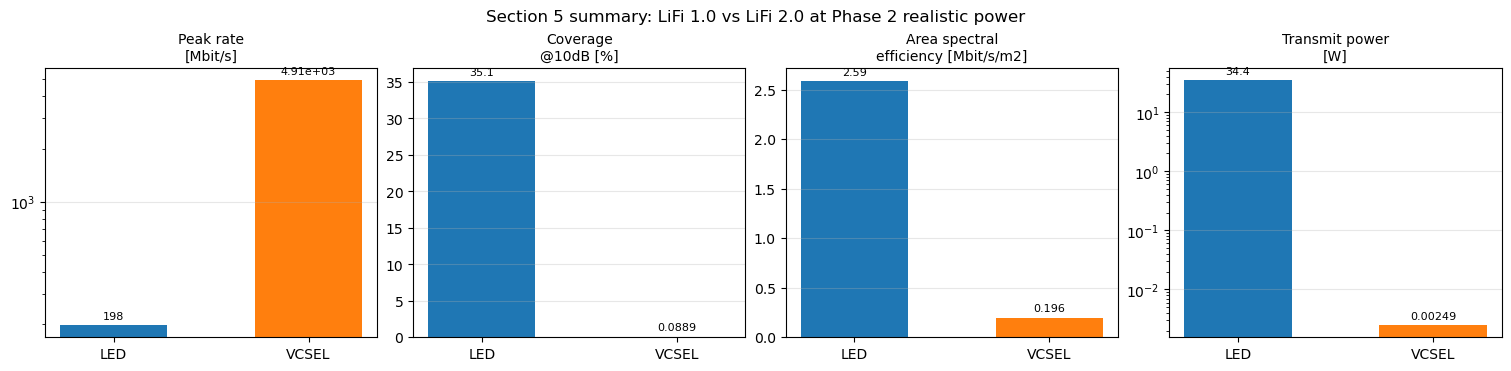

In [21]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6), constrained_layout=True)
bar_specs = [
    ("Peak rate\n[Mbit/s]", np.nanmax(R_led_re) / 1e6, np.nanmax(R_vcsel_eyesafe) / 1e6, True),
    (f"Coverage\n@{GAMMA_TH_DB:.0f}dB [%]", 100 * cov_led_re.mean(), 100 * cov_vcsel_eyesafe_map.mean(), False),
    ("Area spectral\nefficiency [Mbit/s/m2]", spatial_ase(R_led_re) / 1e6, spatial_ase(R_vcsel_eyesafe) / 1e6, False),
    ("Transmit power\n[W]", PTX_LED_REALISTIC, PTX_VCSEL_EYESAFE, True),
]
colors = ["tab:blue", "tab:orange"]
for ax, (label, led_val, vcsel_val, log_scale) in zip(axes, bar_specs):
    bars = ax.bar(["LED", "VCSEL"], [led_val, vcsel_val], color=colors, width=0.55)
    if log_scale:
        ax.set_yscale("log")
    ax.set_title(label, fontsize=10)
    ax.bar_label(bars, fmt="%.3g", fontsize=8, padding=3)
    ax.grid(alpha=.3, axis="y")
fig.suptitle("Section 5 summary: LiFi 1.0 vs LiFi 2.0 at Phase 2 realistic power")
plt.show()

Read as a single row each, the two technologies look almost like different tools: the LED wins on every coverage- and area-related metric (coverage, ASE), while the VCSEL wins on peak rate (roughly 25x), and by orders of magnitude on energy efficiency and on transmit power (it needs thousands of times less). None of this is a flaw in either technology -- it is the direct, simulated consequence of directivity (Section 3) and of what each one's power budget is actually for (Section 4.1-4.2): the LED spreads a lot of power over its whole FoV disk, while the VCSEL concentrates very little power into a spot too small to move the area-averaged numbers. That is exactly the tension the multi-cell notebook picks up next: can either technology's weak metric be fixed by *deploying more of it*?

## 6. Transition to the multi-cell analysis

Every conclusion in Sections 3-5 came from a single transmitter at a single point. Before handing off to the multi-cell notebook, it's worth asking the obvious next question: can a single cell fix its own coverage problem just by using more of the same technology, without yet spreading transmitters across the ceiling?

### 6.1 Why not just add more power at one point?

A natural first instinct is to bundle several VCSELs at the same point. This notebook does not model that configuration, but it is unlikely to scale well: all the power would still land in a single bright spot instead of spreading out, and packing many emitters that closely together would concentrate optical power further, working against the per-emitter eye-safety limits from Section 4.2. Adding emitters only helps if they are aimed at *different* points, not stacked on top of one another.

### 6.2 Tiling multiple beams within a single cell

A more promising idea: keep every emitter at the eye-safe ceiling from Section 4.2 ($P_{tx}=2.49$ mW each), but aim an $m\times m$ grid of them at $m^2$ different points spread across the receiver's own FoV disk (Section 3.3, the only part of the room either technology can be seen from), and use beam selection: only the beam whose aim point is closest to a given receiver location turns on there. This is exactly the mechanism the multi-cell notebook uses per access point, applied here to a single cell first ($n_{AP}=1$). Every eye-safety and power assumption from Section 4.2 stays unchanged: only one beam is ever active at any given point in the room, so it still draws the same 2.49 mW, never more. LiFi 1.0's own Section 4.5-4.6 numbers are carried through as a reference, so the question this section is really asking -- can tiling close the gap with LiFi 1.0 -- has an explicit answer, not just an implied one.

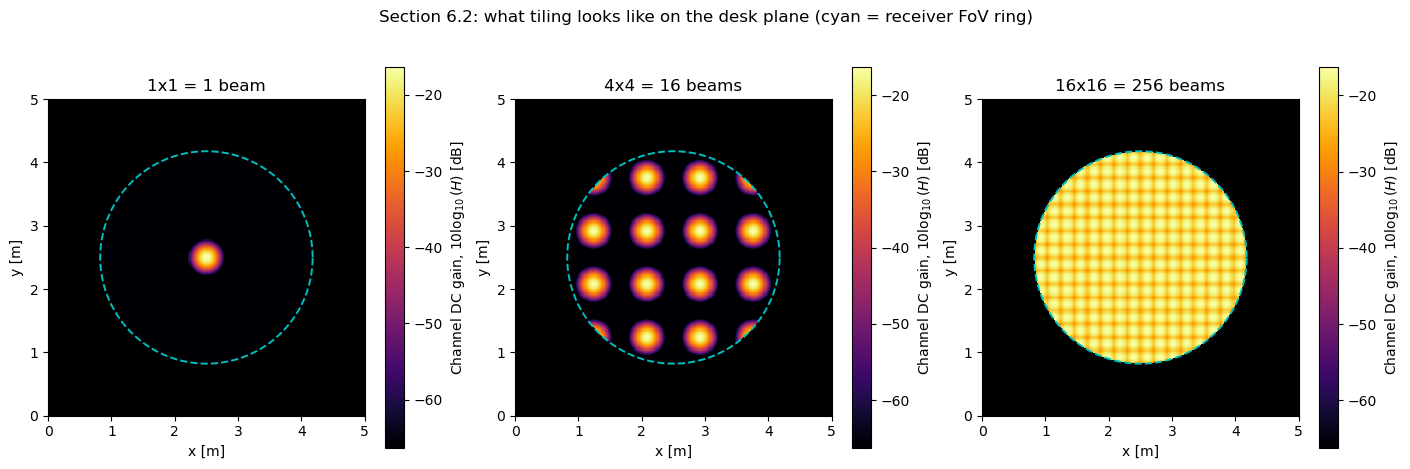

In [22]:
# Section 6.2: tile the single cell's FoV disk with an m x m grid of independently-aimed
# beams, each still at the Section 4.2 eye-safe ceiling, and pick the strongest one at
# each point (beam selection) -- exactly the vcsel_ap_gains mechanism the multi-cell
# notebook applies per access point, just for this one cell (n_AP = 1) first.

def vcsel_tiled_gain(m):
    # tile the m x m beam-aim grid across the FoV disk's own bounding square (side = 2*r_fov,
    # centered under the Tx), not the whole 5x5 m room: points outside the FoV are invisible to
    # the receiver regardless of channel gain (Section 3.1), so aiming beams out there would waste them
    span = 2 * r_fov
    off_x = TX_POS[0] - r_fov + (np.arange(m) + 0.5) * span / m
    off_y = TX_POS[1] - r_fov + (np.arange(m) + 0.5) * span / m
    ox, oy = np.meshgrid(off_x, off_y)
    g_best = np.zeros_like(X)
    for sx, sy in zip(ox.ravel(), oy.ravel()):
        rb = np.hypot(X - sx, Y - sy)               # distance from every rx point to THIS beam's own axis
        d_b = np.sqrt(rb**2 + dz**2)
        wz_b = W0 * np.sqrt(1 + (d_b / zR)**2)
        g = 2 / (np.pi * wz_b**2) * np.exp(-2 * rb**2 / wz_b**2) * APD
        g_best = np.maximum(g_best, g)              # beam selection: keep only the strongest beam at each point
    return np.where(in_fov, g_best * G_CONC, 0.0)

# Visual: what tiling actually looks like on the desk plane, same channel-gain-map style
# as Section 3.3, now showing the beam grid itself at increasing density.
cmap_tiled = plt.cm.inferno.copy()
cmap_tiled.set_bad("black")
th_circle = np.linspace(0, 2 * np.pi, 200)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.8), constrained_layout=True)
for ax, m in zip(axes, [1, 4, 16]):
    H_dB_vis = to_dB(vcsel_tiled_gain(m))
    vmax = np.nanmax(H_dB_vis)
    im = ax.pcolormesh(X, Y, H_dB_vis, shading="auto", cmap=cmap_tiled, vmin=vmax - 50, vmax=vmax)
    ax.plot(TX_POS[0] + r_fov * np.cos(th_circle), TX_POS[1] + r_fov * np.sin(th_circle), "c--", lw=1.4)
    ax.set_title(f"{m}x{m} = {m * m} beam{'s' if m * m > 1 else ''}")
    ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
    ax.set_aspect("equal"); ax.set_xlim(0, ROOM_X); ax.set_ylim(0, ROOM_Y)
    fig.colorbar(im, ax=ax, label=r"Channel DC gain, $10\log_{10}(H)$ [dB]", shrink=0.85)
fig.suptitle("Section 6.2: what tiling looks like on the desk plane (cyan = receiver FoV ring)")
plt.show()

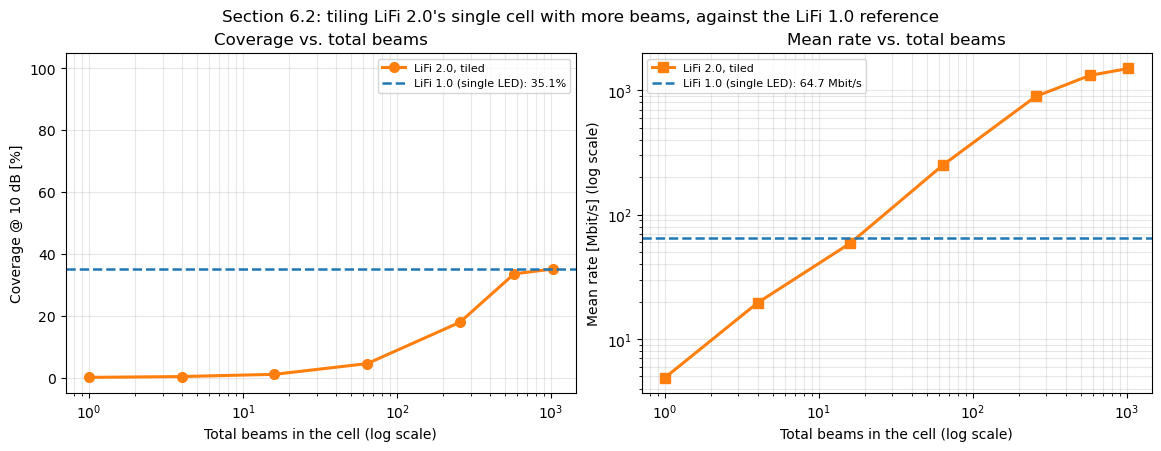

,Beams (m x m),Total beams,Coverage @ 10 dB [%],Mean rate [Mbit/s],ASE [Mbit/s/m2],Peak SNR [dB]
0,1x1,1,0.089,4.89,0.1957,18.3
1,2x2,4,0.360,19.57,0.7827,18.4
2,4x4,16,1.080,59.11,2.3644,18.4
3,8x8,64,4.547,251.48,10.0593,18.4
4,16x16,256,17.916,894.22,35.7687,18.4
5,24x24,576,33.573,1321.85,52.8741,18.4
6,32x32,1024,35.133,1501.65,60.0661,18.4


In [23]:
beam_grid = [1, 2, 4, 8, 16, 24, 32]  # m -> m^2 total beams: 1, 4, 16, 64, 256, 576, 1024
tiled_rows = []
tiled_maps = {}
for m in beam_grid:
    H_tiled = vcsel_tiled_gain(m)
    Pr_tiled = PTX_VCSEL_EYESAFE * H_tiled  # beam selection: the active beam still gets the full Section 4.2 ceiling
    SNR_tiled = (RHO * Pr_tiled)**2 / (N0 * B2)
    R_tiled = 0.5 * B2 * np.log2(1 + K_BOUND * SNR_tiled)
    tiled_maps[m] = (SNR_tiled, R_tiled)
    tiled_rows.append({
        "Beams (m x m)": f"{m}x{m}",
        "Total beams": m * m,
        f"Coverage @ {GAMMA_TH_DB:.0f} dB [%]": round(100 * np.mean(SNR_tiled >= gamma_th), 3),
        "Mean rate [Mbit/s]": round(np.nanmean(R_tiled) / 1e6, 2),
        "ASE [Mbit/s/m2]": round(spatial_ase(R_tiled) / 1e6, 4),
        "Peak SNR [dB]": round(10 * np.log10(np.nanmax(SNR_tiled)), 1),
    })
tiled_df = pd.DataFrame(tiled_rows)

# LiFi 1.0's own numbers at this same threshold (Sections 4.4-4.5), plotted as reference
# lines so the comparison this section is really about -- does tiling let LiFi 2.0 catch up
# with LiFi 1.0 -- is explicit, not just implied.
led_cov_pct = 100 * cov_led_re.mean()
led_mean_rate = np.nanmean(R_led_re) / 1e6

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4), constrained_layout=True)
totals = tiled_df["Total beams"]
axes[0].plot(totals, tiled_df[f"Coverage @ {GAMMA_TH_DB:.0f} dB [%]"], "o-", color="tab:orange", lw=2.2, ms=7,
             label="LiFi 2.0, tiled")
axes[0].axhline(led_cov_pct, color="tab:blue", ls="--", lw=1.8, label=f"LiFi 1.0 (single LED): {led_cov_pct:.1f}%")
axes[0].set_xscale("log")
axes[0].set_ylim(-5, 105)
axes[0].set_xlabel("Total beams in the cell (log scale)")
axes[0].set_ylabel(f"Coverage @ {GAMMA_TH_DB:.0f} dB [%]")
axes[0].set_title("Coverage vs. total beams")
axes[0].legend(fontsize=8); axes[0].grid(alpha=.3, which="both")

axes[1].plot(totals, tiled_df["Mean rate [Mbit/s]"], "s-", color="tab:orange", lw=2.2, ms=7,
             label="LiFi 2.0, tiled")
axes[1].axhline(led_mean_rate, color="tab:blue", ls="--", lw=1.8,
                label=f"LiFi 1.0 (single LED): {led_mean_rate:.1f} Mbit/s")
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_xlabel("Total beams in the cell (log scale)")
axes[1].set_ylabel("Mean rate [Mbit/s] (log scale)")
axes[1].set_title("Mean rate vs. total beams")
axes[1].legend(fontsize=8); axes[1].grid(alpha=.3, which="both")
fig.suptitle("Section 6.2: tiling LiFi 2.0's single cell with more beams, against the LiFi 1.0 reference")
plt.show()

tiled_df

Tiling more beams helps a lot on rate, but not enough to close LiFi 2.0's coverage gap with LiFi 1.0 within a single cell, at least not at the beam count this notebook ends up settling on. At $m=1$ (a single beam at the cell's center) this reproduces Section 4.4-4.5's own numbers exactly: 18.3 dB peak SNR, 0.09% coverage @ 10 dB, 0.20 Mbit/s/m² ASE -- a useful check that the tiling model collapses back to the already-established single-beam case. Mean rate keeps climbing throughout the sweep (4.9 -> 894 -> 1502 Mbit/s from 1 to 256 to 1024 beams), but each fourfold jump in beam count buys less than the last: going from 256 to 1024 beams adds about 68% more rate, against a 183x gain from 1 to 256.

Coverage climbs too (0.09% -> 17.9% -> 35.1% from 1 to 256 to 1024 beams), and it does eventually reach LiFi 1.0's own 35.1% (Section 4.4) once enough beams tile the FoV disk finely enough -- LiFi 2.0 converges on the same geometric ceiling the LED already fills for free with its wide Lambertian lobe. At 256 beams specifically, though, coverage is still only 17.9%: catching up takes roughly 1024 beams here, not 256.

256 beams/AP (16x16) is still the number adopted for the multi-cell notebook that follows. The marginal rate per added beam drops sharply right around this point (about 3.3 Mbit/s per beam from 64 to 256, falling to about 1.3 from 256 to 576 and about 0.4 from 576 to 1024), so it sits at the edge of the steep part of the curve, just before the returns flatten out. A 16x16 grid is also a simple, round tiling to reason about -- simplicity, not optimality (which would keep pushing toward more beams, at ever-smaller gains), is the deciding factor here, the same standard already applied to beam selection itself as a simplification of full precoding (Section 6.1).

That split -- more beams help throughput a lot and coverage eventually, but 256 alone only gets partway there -- is exactly what motivates moving beyond a single cell. The multi-cell notebook that follows takes this same beam-tiling mechanism and adds the other lever this section couldn't use: more access points, each contributing its own FoV disk, so covering the whole room becomes a question of density rather than of how finely one cell's beams are sliced.

`[VCSEL-Precoding]` proposes an array distributed over the ceiling, precoded so that different (possibly overlapping) subsets of elements serve different users at once, instead of every element aiming at the same spot. The multi-cell notebook that follows takes this distributed-array idea as its starting point, but simplifies it to beam selection (one active emitter per access point at a time) instead of implementing full precoding -- the same simplification already used above -- and, as in this notebook, only assumes coherent *emission* from each VCSEL (what gives it a narrow, well-defined beam), never phase-encoded information.

The next stage moves from this single-transmitter analysis to a multi-cell one: several of these tiled cells placed across the ceiling at once, to see what a spatially distributed array actually achieves for coverage uniformity and multi-user capacity once neighbouring cells start interfering with each other, not just for what one cell can do on its own.